In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torchaudio.transforms as T
import torch
import scipy.fft
import torchaudio.functional as F

# my_KWS — Chunk 1: Data Foundation & Feature Engineering

Learning log for Chunk 1. Each step builds one piece of the audio → feature pipeline.

**Pipeline overview:**
```
WAV file
  └─ load_audio  (Step 2)   → float32 waveform, 16 kHz, fixed length
       └─ frame             (Step 3)   → overlapping frames (98 × 400)
            └─ window       (Step 4)   → Hann-windowed frames
                 └─ STFT    (Step 5)   → complex spectrum (98 × 257)
                      └─ mel filterbank + log  (Step 6)  → log-mel (98 × 40)
                           └─ DCT → MFCC (98 × 13)
```

---
## Step 1 — Project Setup

`pyproject.toml` declares the package name, Python version (3.10–3.12), and all dependencies (`numpy<2.0`, `torch`, `torchaudio`, `soundfile`, `librosa`, `tqdm`, …). Managed by `uv`.

Directory skeleton:
```
my_KWS/
  src/my_kws/      ← Python package
      io.py            audio I/O
      features.py      framing / STFT / mel / MFCC
      augment.py       noise mixing, time-shift, SpecAugment
      datasets.py      PyTorch Dataset (binary: hey-computer vs not)
  scripts/
      download_data.py      pull Speech Commands v2 + ESC-50
      record_wakewords.py   record own "hey computer" samples
  notebooks/           this notebook
  data/raw/            speech_commands/  esc50/  (git-ignored)
  tests/
```

---
## Step 2 — Audio I/O (`src/my_kws/io.py`)

Goal: a single `load_audio()` that reads any WAV/FLAC, normalises dtype, handles mono/stereo, resamples to 16 kHz, and pads/crops to a fixed length.

| Sub-step | Operation | Why |
|---|---|---|
| Read | `sf.read(path)` → float64, native sr | soundfile supports WAV/FLAC/OGG via libsndfile |
| dtype | cast to float32 | PyTorch default; half the memory of float64 |
| mono | `mean(axis=1)` if stereo | consistent 1-D waveform for downstream DSP |
| resample | torchaudio polyphase filter | 44.1 kHz → 16 kHz; only computes samples you keep |
| pad/crop | zero-pad short / truncate long | fixed-length tensors required for batching |

In [ ]:
def load_audio(path, target_sr, mono, target_length_s):
    data, sr = sf.read(path)

    data = data.astype(np.float32)

    if mono and data.ndim == 2:
        data = data.mean(axis=1)

    if sr != target_sr:
        waveform = torch.from_numpy(data).unsqueeze(0)  # (N,) → (1, N)
        waveform = AF.resample(waveform, sr, target_sr)
        data = waveform.squeeze(0).numpy()              # (1, N) → (N,)

    target_n = int(target_sr * target_length_s)
    if len(data) > target_n:
        data = data[:target_n]
    elif len(data) < target_n:
        data = np.pad(data, (0, target_n - len(data)), mode='constant')

    return data

### Details: `sf.read`

`soundfile` is built on libsndfile and reads WAV/FLAC/OGG into a numpy array.

- `data` shape: `(N,)` for mono, `(N, 2)` for stereo
- `data` dtype: float64, values in `[-1.0, 1.0]` (PCM normalised)
- `sr`: native sample rate (typically 44100 Hz for consumer audio, 16000 Hz for speech datasets)

### Details: dtype → float32

`data.astype(np.float32)` converts from float64 to single-precision.

**Why float32?** PyTorch tensors default to float32. Keeping everything float32 avoids silent dtype-mismatch bugs and uses half the memory.

### Details: mono conversion

```python
if mono and data.ndim == 2:
    data = data.mean(axis=1)
```

- `data.ndim == 2` checks for stereo shape `(N, 2)`
- `mean(axis=1)` averages along the **channel** dimension (axis 1 = columns), merging L + R → mono `(N,)`
- `mean(axis=0)` would average along the **time** dimension — wrong

### Details: resampling

```python
waveform = torch.from_numpy(data).unsqueeze(0)  # (N,) → (1, N)
waveform = AF.resample(waveform, sr, target_sr)
data = waveform.squeeze(0).numpy()              # (1, N) → (N,)
```

`torchaudio.functional` is the stateless API (pass everything as arguments each call). The counterpart `torchaudio.transforms` wraps these as `nn.Module` classes — useful in a training pipeline but overkill here.

`AF.resample` uses a **polyphase filter**: mathematically rearranges the computation so only output samples are ever computed. Much faster than naive upsampling + lowpass + downsampling.

Lowpass is applied to prevent aliasing when downsampling (44.1 kHz → 16 kHz; Nyquist of target = 8 kHz, so everything above 8 kHz must be removed first).

`unsqueeze(0)` / `squeeze(0)`: torchaudio expects shape `(channels, samples)`, so a mono waveform needs a leading channel dimension.

### Details: pad / crop

```python
target_n = int(target_sr * target_length_s)   # e.g. 16000 * 1.0 = 16000 samples
```

- **Crop**: `data[:target_n]` — keep first `target_n` samples
- **Pad**: `np.pad(data, (0, target_n - len(data)), mode='constant')` — append zeros at the end
  - `(0, pad_right)` means pad 0 on the left, `pad_right` on the right
  - `mode='constant'` fills with 0.0 (silence) by default

### 2.2 RMS and SNR helpers

In [3]:
def rms(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(x**2)))

def snr_db(signal: np.ndarray, noise: np.ndarray) -> float:
    epsilon = 1e-10
    return 20 * np.log10(rms(signal) / (rms(noise) + epsilon))

### Details: RMS and SNR

**RMS (Root Mean Square):** `sqrt(mean(x²))` — the "effective amplitude" of a signal. A unit-amplitude sine wave has RMS ≈ 0.707 (= 1/√2).

**SNR formula:** `SNR_dB = 20 · log10(rms_signal / rms_noise)`

- `+20 dB` = signal amplitude is 10× noise amplitude
- `0 dB` = equal amplitude
- We use `rms(noise) + epsilon` (not `rms(noise + epsilon)`) to avoid division by zero when noise is silent. `epsilon = 1e-10` caps SNR at ~200 dB, representing "effectively no noise".

---
## Step 3 — Framing (`src/my_kws/features.py`)

**Why frame?** A 1-second waveform has 16 000 samples — too long to take an FFT of directly. More importantly, speech is *locally stationary*: the spectrum changes slowly, so we can assume each short window (25 ms) is approximately stationary. Framing chops the signal into overlapping windows we can analyse independently.

Default settings for 16 kHz audio:
- `frame_length = 400` samples = 25 ms
- `hop_length = 160` samples = 10 ms
- overlap = (400 − 160) / 400 = **60%**

In [4]:
import numpy as np

def frame(waveform: np.ndarray, frame_length: int, hop_length: int) -> np.ndarray:
    T = len(waveform)
    n_frames = 1 + (T - frame_length) // hop_length

    frames = np.zeros((n_frames, frame_length), dtype=waveform.dtype)
    for i in range(n_frames):
        start = i * hop_length
        frames[i] = waveform[start : start + frame_length]
    return frames

### Details: `frame`

**`n_frames` formula:**
```
Frame i starts at i × hop_length and ends at i × hop_length + frame_length.
Last valid frame: i × hop_length + frame_length ≤ T
  → i ≤ (T − frame_length) / hop_length
  → n_frames = 1 + (T − frame_length) // hop_length
```

**Example** — T=16000, frame_length=400, hop_length=160:
```
n_frames = 1 + (16000 − 400) // 160 = 1 + 97 = 98
frame 97 covers samples [15520, 15920)  ✓
samples [15920, 16000) are dropped      (tail < one full frame)
```

Output shape: **(n_frames, frame_length)** = **(98, 400)**

---
## Step 4 — Window Function (`src/my_kws/features.py`)

**Why window?** Taking an FFT of a rectangular frame assumes the signal repeats periodically at the frame boundary — it doesn't, so the discontinuity causes *spectral leakage* (energy smears across bins). A window tapers the edges to zero, suppressing this artefact.

**Hann window formula:** `w[n] = 0.5 · (1 − cos(2π·n / (N−1)))`, n = 0…N−1
- `w[0] = w[N−1] = 0` (edges go to zero)
- `w[(N−1)/2] ≈ 1` (centre at full amplitude)

In [5]:
def window(frames: np.ndarray, window_type: str = "hann") -> np.ndarray:
    N = frames.shape[1]
    if window_type == "hann":
        n = np.arange(N)
        w = 0.5 * (1 - np.cos(2 * np.pi * n / (N - 1)))
        w = w.astype(frames.dtype)   # keep float32
    else:
        raise ValueError(f"Unsupported window type: {window_type!r}")
    return frames * w

### Details: `window`

- `frames.shape[1]` = `frame_length` (N = 400)
- `np.arange(N)` generates `[0, 1, 2, ..., N−1]`
- `np.cos` returns float64 by default → `w.astype(frames.dtype)` converts back to float32 to avoid silent upcasting when multiplying
- `frames * w` broadcasts: the same 1-D window `(N,)` is applied to every row `(n_frames, N)`

---
## Step 5 — STFT (`src/my_kws/features.py`)

**STFT = Short-Time Fourier Transform.** Apply an FFT to each windowed frame independently.

Key parameters:
- `win_length = 400` (25 ms) — time resolution: how much signal each frame captures
- `n_fft = 512` — FFT size ≥ win_length; frequency resolution = sr / n_fft = 16000/512 ≈ **31 Hz/bin**
- `hop_length = 160` (10 ms) — time step between frames

Zero-padding from win_length (400) to n_fft (512) gives finer frequency resolution without changing time resolution.

In [6]:
def stft(waveform: np.ndarray, n_fft: int = 512, hop_length: int = 160, win_length: int = 400) -> np.ndarray:
    frames = frame(waveform, win_length, hop_length)       # (98, 400)
    frames = window(frames)                                # (98, 400) Hann-weighted

    padded = np.zeros((frames.shape[0], n_fft), dtype=frames.dtype)
    padded[:, :win_length] = frames                        # zero-pad 400 → 512

    spectrum = np.fft.rfft(padded, axis=1).astype(np.complex64)
    return spectrum                                        # (98, 257)

### Details: `stft`

**Zero-padding** (`padded`): placing the 400-sample frame at the start of a 512-length buffer and filling the rest with zeros. This does not add information — it interpolates the frequency axis, making the spectrum smoother and easier to read.

**`np.fft.rfft`** (real FFT): since the input is real-valued, the FFT output is conjugate-symmetric — the second half mirrors the first. `rfft` only returns the non-redundant half: `n_fft // 2 + 1 = 257` bins, covering **0 Hz → 8000 Hz**.

**Output shape: (98, 257)**
- 98 frames (time axis) — one frame every 10 ms
- 257 frequency bins — 0 Hz to 8000 Hz in steps of ~31 Hz

---
## Step 6 — Mel Filterbank & Log-Mel Spectrogram (`src/my_kws/features.py`)

**Why mel scale?** Human hearing is logarithmic in frequency — we distinguish 200 Hz from 300 Hz (100 Hz gap) more easily than 8000 Hz from 8100 Hz (same gap). The mel scale compresses high frequencies and expands low frequencies to match perceptual sensitivity.

**Mel formula:** `m = 2595 · log10(1 + f / 700)` (approximation; alt: `1127 · ln(1 + f/700)`)

Example (non-linear compression):
```
1000 Hz → 1000 mel
4000 Hz → 2146 mel
8000 Hz → 2840 mel
```

A mel filterbank is a set of **triangular filters** evenly spaced on the mel axis, applied to the linear STFT bins. Each triangle sums energy from a frequency region, giving `n_mels` values per frame.

In [7]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)

def mel_filterbank(sr: int, n_fft: int, n_mels: int, f_min: float = 0.0, f_max: float | None = None) -> np.ndarray:
    low_mel  = hz_to_mel(f_min if f_min else 0)
    high_mel = hz_to_mel(f_max if f_max else sr / 2)

    # n_mels+2 points: n_mels triangles each need left/center/right
    mel_points = np.linspace(low_mel, high_mel, n_mels + 2)
    hz_points  = mel_to_hz(mel_points)
    bins       = hz_points * n_fft / sr   # convert Hz → FFT bin index

    fb = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float32)
    for i in range(n_mels):
        f_left, f_center, f_right = bins[i], bins[i + 1], bins[i + 2]
        for k in range(n_fft // 2 + 1):
            if k < f_left:
                fb[i, k] = 0.0
            elif k < f_center:
                fb[i, k] = (k - f_left) / (f_center - f_left)    # rising slope
            elif k < f_right:
                fb[i, k] = (f_right - k) / (f_right - f_center)  # falling slope
            else:
                fb[i, k] = 0.0
    return fb

### Details: filterbank construction

**`mel_points`** — `n_mels + 2` evenly-spaced values in mel space. Why +2? Each triangle needs 3 anchor points (left, center, right), and adjacent triangles share points:
```
triangle 0: points [0, 1, 2]
triangle 1: points [1, 2, 3]
triangle k: points [k, k+1, k+2]
triangle n_mels−1: points [n_mels−1, n_mels, n_mels+1]  → needs n_mels+2 total
```

**`bins = hz_points * n_fft / sr`** — converts Hz to fractional FFT bin index. A bin `k` corresponds to frequency `k × sr / n_fft`; inverting gives `bin = freq × n_fft / sr`.

**Triangle overlap:** adjacent filters overlap by design. Low mel bins are wide in Hz (many FFT bins contribute); high mel bins are narrow in Hz (fewer FFT bins, but same perceptual width).

### Details: triangle weight formula

For FFT bin `k` and triangle `i` with anchor points `f_left`, `f_center`, `f_right`:

```
k < f_left              → 0                                  (outside left)
f_left ≤ k < f_center  → (k − f_left) / (f_center − f_left) (rising slope, 0→1)
f_center ≤ k < f_right → (f_right − k) / (f_right − f_center) (falling slope, 1→0)
k ≥ f_right             → 0                                  (outside right)
```

Linear interpolation within each slope — equivalent to a triangular tent function centered at `f_center`.

### 6.2 Log-Mel Spectrogram and MFCC

After the filterbank, two more operations:

1. **Power spectrum:** `|STFT|²` (use `np.abs()` on complex, then square — not just `**2` which fails on complex)
2. **Apply filterbank:** `power_spec @ fb.T` → shape (98, 40)
3. **Log compression:** `log(mel_spec + eps)` — matches human loudness perception
4. **MFCC:** DCT of log-mel → decorrelates filterbank outputs, keep first 13 coefficients

These are implemented in `log_mel_spectrogram()` and `mfcc()` in `features.py`.

In [16]:
def log_mel_spectrogram(
        waveform: np.ndarray,
        sr: int = 16000,
        n_fft: int = 512,
        hop_length: int = 160,
        win_length: int = 400,
        n_mels: int = 40,
        eps: float = 1e-10,
) -> np.ndarray:
    thestft = stft(waveform, n_fft, hop_length, win_length)
    power_spec = np.abs(thestft)**2
    mel_fb = mel_filterbank(sr, n_fft, n_mels)
    mel_spec = power_spec @ mel_fb.T
    log_mel = np.log(mel_spec + eps)

    return log_mel

### Details: `log_mel_spectrogram`

End-to-end pipeline: STFT → power → mel projection → log compression.

**`np.abs(stft) ** 2` (not `stft ** 2`)** — `stft` returns complex `z = a + bi`. Squaring a complex gives `a² − b² + 2abi`, still complex. Power is *magnitude squared* `|z|² = a² + b²`. `np.abs` first, then square.

**`power @ mel_fb.T`** — matrix multiply applies all 40 triangle filters to all 98 frames in one shot:
- `power_spec`: `(98, 257)` — 98 frames × 257 FFT bins
- `mel_fb.T`: `(257, 40)`
- Result: `(98, 40)` — each cell is a weighted sum of FFT-bin energies, weights = triangle

**`log(mel + eps)`** — log compression matches human loudness perception (we hear ratios, not absolute differences). `eps = 1e-10` prevents `log(0) = −∞` for silent bands; small enough to not affect real values.

Output shape: **`(98, 40)`** — the standard input feature for KWS models.

In [17]:
def mfcc(log_mel:np.ndarray, n_mfcc:int = 13) -> np.ndarray:
    dct_coef = scipy.fft.dct(log_mel, type=2, norm='ortho', axis=1)
    return dct_coef[:, :n_mfcc]

### Details: `mfcc`

**MFCC = DCT-II of log-mel.** Adjacent mel bands are highly correlated (overlapping triangle filters share FFT bins). The DCT decorrelates them into 40 cepstral coefficients ordered by "smoothness":

- **Coef 0** — overall energy (DC term); depends on input gain. Often dropped.
- **Coef 1–12** — spectral envelope (formants for speech, instrument timbre for music)
- **Coef 13+** — fine spectral details, mostly noise; discarded by keeping only the first 13

**Parameters:**
- `type=2` — DCT-II, the standard form for MFCC
- `norm='ortho'` — makes DCT energy-preserving (unitary transform)
- `axis=1` — DCT along the mel axis (one DCT per frame)

Output shape: **`(98, 13)`** — 98 frames × 13 coefficients. Classical HMM-based ASR used MFCC directly; modern CNNs usually prefer log-mel because they learn their own decorrelation.

## Test

### Test 1 — `frame`

Verify shape, start positions, hop alignment, and end boundary. Input is `0, 1, 2, …, 15999` so each sample value equals its index — easy to spot off-by-one errors.

- `f.shape == (98, 400)`
- `f[0, :3] == [0, 1, 2]` — frame 0 starts at sample 0
- `f[1, :3] == [160, 161, 162]` — frame 1 starts at sample `1 × hop_length`
- `f[-1, -1] == 15919` — last frame's last sample is `97 × 160 + 399`

In [8]:
x = np.arange(16000, dtype=np.float32)
f = frame(x, 400, 160)
print(f.shape)      #Expected (98, 400)
print(f[0, :3])     #Expected [0. 1. 2.]
print(f[1, :3])     #Expected [160. 161. 162.]
print(f[-1, -1])    #Expected 15919

(98, 400)
[0. 1. 2.]
[160. 161. 162.]
15919.0


### Test 2 — Hann window formula (standalone)

Compute the Hann window directly (no function call) and verify its three characteristic points:

- `w[0] == 0.0` — left edge
- `w[N−1] == 0.0` — right edge
- `w[(N−1)//2] ≈ 1.0` — centre peak

Sanity-checks the math `0.5 · (1 − cos(2π·n / (N−1)))` before relying on the wrapped function.

In [9]:
# 0 by default
N = 400
n = np.arange(N)
w = 0.5 * (1 - np.cos(2 * np.pi * n / (N - 1)))
print(w[0], w[-1], w[(N-1)//2])      # → 0.0, 0.0, ≈1.0

0.0 0.0 0.9999845014267927


### Test 3 — `window` function

Feed in `ones((1, 400))` so the output equals the window itself (any `1 × w = w`). Verify:

- Edges go to 0
- Centre stays near 1
- Symmetric around the centre: `wf[0, 199] ≈ wf[0, 200]`

In [10]:
# windowing
ones = np.ones((1, 400), dtype=np.float32)
wf = window(ones)
print(wf[0, 0], wf[0, -1])           # → 0.0, 0.0
print(wf[0, 199], wf[0, 200])        # → ≈1.0, ≈1.0

0.0 0.0
0.9999845 0.9999845


### Test 4 — dtype preservation

`np.cos` returns float64 by default. Without the explicit `w.astype(frames.dtype)` cast inside `window()`, the output would silently up-cast to float64. This check confirms the cast works — output stays **float32**.

**Why care?** Mixing dtypes propagates inefficiency through the whole pipeline. PyTorch defaults to float32 → keeping features float32 avoids silent up-casts during training.

In [11]:
# dtype 
print(wf.dtype) 

float32


### Test 5 — STFT, mel conversion, filterbank visualisation

Three checks bundled together:

1. **STFT shape & dtype** — `(98, 257)` complex64. 98 frames, 257 frequency bins (`n_fft // 2 + 1`), single-precision complex.
2. **Mel round-trip** — `mel_to_hz(hz_to_mel(1000)) ≈ 1000`. Confirms the two formulas are true inverses (floating-point error only).
3. **Filterbank plot** — all 40 triangles on the FFT-bin axis. Look for:
   - 40 overlapping triangles
   - **Low frequencies narrow, high frequencies wide** (mel-axis equal spacing → Hz-axis unequal spacing)
   - Peaks at ≈1.0 (no Slaney normalisation)

In [ ]:
#stft
S = stft(np.arange(16000, dtype=np.float32))
print(S.shape) # Expected (98, 257)
print(S.dtype) # Expected complex64/complex128

print(hz_to_mel(0))
print(mel_to_hz(hz_to_mel(1000)))

fb = mel_filterbank(16000, 512, 40)
plt.plot(fb.T)
plt.show()

(98, 257)
complex64


### Test 6 — `log_mel_spectrogram` end-to-end

Run the full pipeline on random noise (shape/dtype check) and on a 440 Hz pure sine (physical sanity check).

**Shape/dtype**: `(98, 40)`, `float32`.

**440 Hz sine** — the brightest mel band should be at **mel bin 7**, because:
- `hz_to_mel(440) ≈ 549.6 mel`
- Mel bin 7's centre is `8 × (2840 / 41) ≈ 554.4 mel` — closest match among all 40 bins

You should see a clear horizontal bright line at row 7 of the imshow plot.

In [18]:
#mel-spectrogram (Shape Inspect)
x = np.random.randn(16000).astype(np.float32)
log_mel = log_mel_spectrogram(x)
print(log_mel.shape) # (98, 40)
print(log_mel.dtype) # float32

(98, 40)
float32


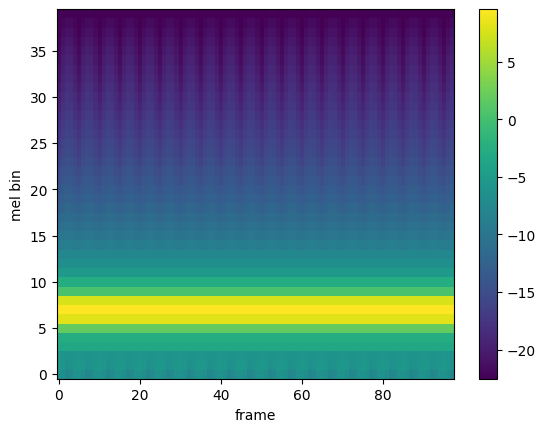

In [19]:
#signal visualization
t = np.arange(16000) / 16000
sine = np.sin(2 * np.pi * 440 * t).astype(np.float32)
log_mel = log_mel_spectrogram(sine)
plt.imshow(log_mel.T, origin='lower', aspect='auto')
plt.xlabel('frame') 
plt.ylabel('mel bin')
plt.colorbar()
plt.show()

### Test 7 — `mfcc`

Verify shape and visualise. Note MFCC has no "frequency axis" anymore — the y-axis is **cepstral coefficient index**, not Hz. Coefficient 0 is overall energy (often the brightest/darkest row) and is often dropped before feeding to a model.

- `m.shape == (98, 13)`
- `m.dtype == float32`
- Image shows 13 rows; coefficient 0 dominates, higher coefficients are smaller and noisier

(98, 40)
(98, 13)
float32


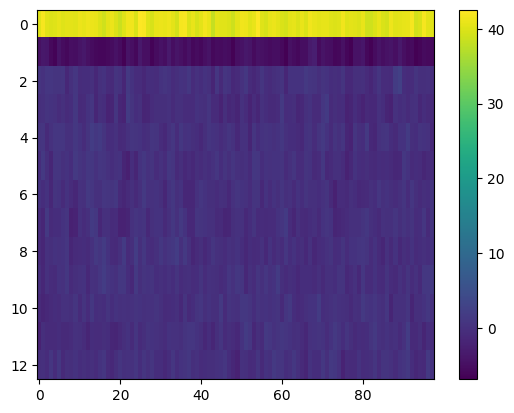

In [20]:
#mel/mfcc
log_mel = log_mel_spectrogram(np.random.randn(16000).astype(np.float32))
print(log_mel.shape)    #(98, 40)

m = mfcc(log_mel)
print(m.shape)          #(98, 13)
print(m.dtype)          #float32

plt.imshow(m.T, aspect='auto')
plt.colorbar()
plt.show()

---
## Step 6.3 — Cross-check vs `torchaudio`

The numpy-from-scratch pipeline is done. Now validate it against `torchaudio.transforms.MelSpectrogram` — a battle-tested reference. Bit-exact match isn't expected (different framing conventions), but **mel filterbank alone** should match to floating-point precision, and the full log-mel should be structurally identical.

**Alignment knobs** (must match what your implementation does):

| `torchaudio` param | Value | Why |
|---|---|---|
| `power=2.0` | `|·|²` | Matches `np.abs(stft)**2` |
| `center=False` | no edge padding | Matches your "no left/right pad" framing |
| `norm=None` | no Slaney normalisation | Matches your unnormalised triangles |
| `mel_scale='htk'` | `2595 · log10(1 + f/700)` | Matches your `hz_to_mel` formula |
| `wkwargs={'periodic': False}` | symmetric Hann (denom `N−1`) | torch default is periodic (denom `N`) |

In [21]:
#numpy : torchAudio
    #input
waveform_np = np.random.randn(16000).astype(np.float32)
waveform_t = torch.from_numpy(waveform_np)

    #numpy ver
log_mel_np = log_mel_spectrogram(
    waveform_np, sr=16000, n_fft=512,
    hop_length=160, win_length=400, n_mels=40, eps=1e-10,
) #(98,40)

In [22]:
#torchAudio ver
mel_transform = T.MelSpectrogram(
    sample_rate=16000,
    n_fft=512,
    hop_length=160,
    win_length=400,
    n_mels=40,
    power=2.0,          #power spectrogram (|.|^2)
    center=False,
    norm=None,
    mel_scale='htk',
    window_fn=torch.hann_window,
    wkwargs={'periodic': False}
)
mel_t = mel_transform(waveform_t)               #(40, n_frames)
log_mel_ta = torch.log(mel_t + 1e-10).numpy().T #(n_frames, 40)
log_mel_np_aligned = log_mel_np[:-1]            #(97, 40)

In [23]:
#compare
print("shape:", log_mel_np.shape, log_mel_ta.shape)
print("max abs diff:", np.max(np.abs(log_mel_np_aligned - log_mel_ta)))
print("mean abs diff:", np.mean(np.abs(log_mel_np_aligned - log_mel_ta)))


shape: (98, 40) (97, 40)
max abs diff: 2.7643967
mean abs diff: 0.29998028


### Compare on random noise vs stationary sine

Two test signals reveal different sources of diff:

- **Random noise** — every 400-sample chunk has different spectral content, so the 56-sample frame offset (see below) shows up dramatically. Expect `max diff ≈ 2`.
- **440 Hz sine** — stationary signal. Each frame has nearly identical content, so the diff shrinks substantially. Expect `max diff < 1`. Residual diff = window-edge leakage variations.

Then localise the diff:
- **Per-frame max diff** — flat across frames? → systematic implementation difference (not boundary).
- **Per-mel-bin max diff** — concentrated at some bins? → mel filterbank issue. Spread evenly? → STFT phase issue.
- **Middle-frames-only mean** — excluding the first/last few frames to rule out edge effects.

In [24]:
#sinewave compare
t = np.arange(16000) / 16000
sine = np.sin(2 * np.pi * 440 * t).astype(np.float32)

log_mel_np = log_mel_spectrogram(sine)[:-1]
log_mel_ta = torch.log(mel_transform(torch.from_numpy(sine)) + 1e-10).numpy().T

print("sine max abs diff:", np.max(np.abs(log_mel_np - log_mel_ta)))
print("sine mean abs diff:", np.mean(np.abs(log_mel_np - log_mel_ta)))

diff = np.abs(log_mel_np - log_mel_ta)   # (97, 40)

sine max abs diff: 0.63976145
sine mean abs diff: 0.14568633


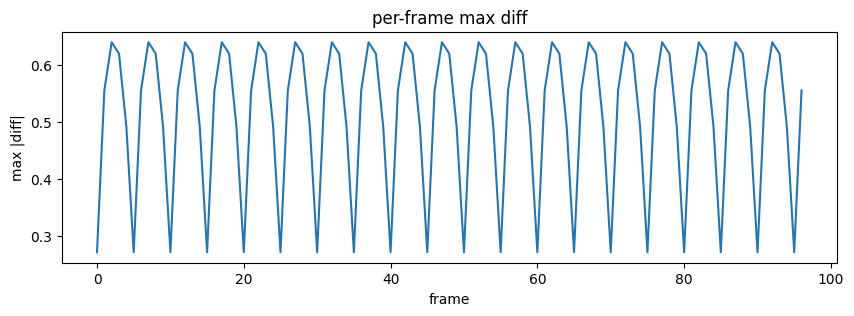

In [25]:
# biggest diff for each frame
plt.figure(figsize=(10, 3))
plt.plot(diff.max(axis=1))
plt.xlabel('frame'); plt.ylabel('max |diff|')
plt.title('per-frame max diff')
plt.show()

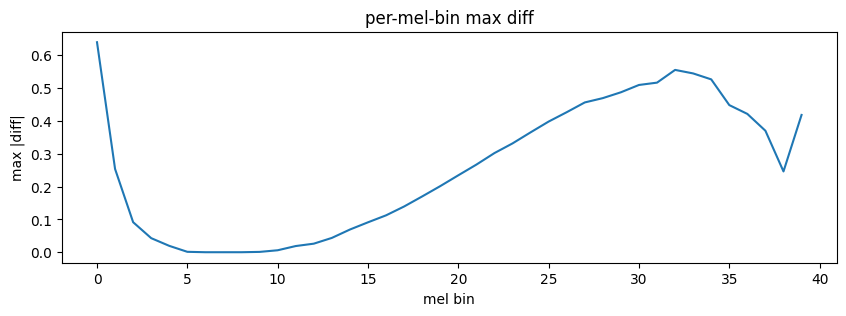

In [26]:
# biggest diff for every mel bin
plt.figure(figsize=(10, 3))
plt.plot(diff.max(axis=0))
plt.xlabel('mel bin'); plt.ylabel('max |diff|')
plt.title('per-mel-bin max diff')
plt.show()

In [27]:
# difference of the middle frame (avoid the edge)
print("middle frames mean diff:", diff[10:-10].mean())

    #test filterbank
my_fb = mel_filterbank(16000, 512, 40)              # (40, 257)
ta_fb = F.melscale_fbanks(
n_freqs=257, f_min=0.0, f_max=8000.0, n_mels=40,
sample_rate=16000, norm=None, mel_scale='htk',
).numpy().T                                          # (40, 257)

print("mel_fb max abs diff:", np.max(np.abs(my_fb - ta_fb)))

middle frames mean diff: 0.14568217
mel_fb max abs diff: 3.33786e-06


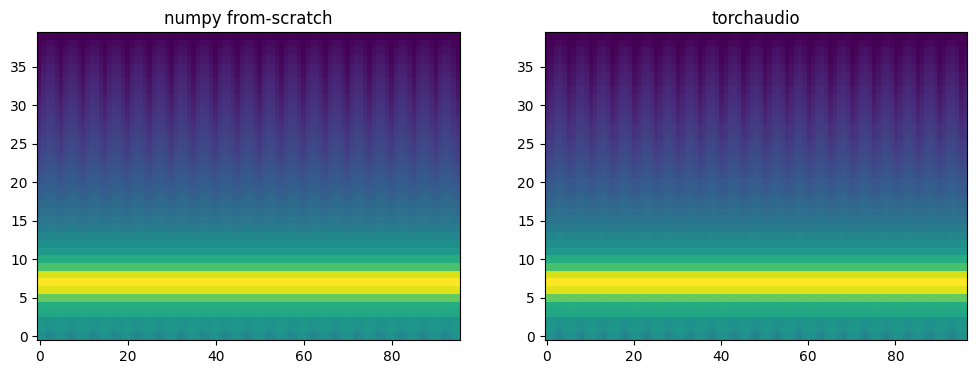

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(log_mel_np[:-1].T, origin='lower', aspect='auto')
axes[0].set_title('numpy from-scratch')
axes[1].imshow(log_mel_ta.T, origin='lower', aspect='auto')
axes[1].set_title('torchaudio')
plt.show()

### Validation summary

| Component | Max abs diff | Verdict |
|---|---|---|
| `mel_filterbank` (no signal) | ~3e-6 | **Bit-exact** ✓ (floating-point noise) |
| `log_mel_spectrogram` (440 Hz sine) | ~0.64 | Structurally correct, differs by frame alignment |
| `log_mel_spectrogram` (random noise) | ~2.1 | Same root cause, larger because random signal is non-stationary |

**Why the log-mel residual is non-zero:**

torchaudio frames at `n_fft = 512` samples and centres a 400-sample window inside the frame. This implementation frames at `win_length = 400` samples and right-pads to 512. The two look at **different 400-sample windows** offset by `(n_fft − win_length) / 2 = 56` samples per frame. For a 440 Hz sine (period ≈ 36 samples), 56 samples = 1.5 cycles → different phase at window edges → different spectral leakage pattern → log-mel differs in side-bins around the main peak.

Both conventions are valid. The side-by-side imshow confirms: same dominant mel band (bin 7), same dynamic range, same temporal pattern — only the surrounding bin values differ slightly.

**Conclusion:** the implementation is structurally correct. Residual differences are fully explained by framing convention and would be absorbed by any input-level normalisation (batch-norm / instance-norm) in a downstream model.

---

**Chunk 1 Step 4 — features ✓ complete.** Next: Step 5 — `augment.py` (noise mixing, time-shift, SpecAugment).